# Credit Card Customer Segmentation

**A K-Means clustering case study for targeted marketing and risk monitoring**

## Business problem

A bank or card issuer treating every customer the same way leaves money on the table and misses
early risk signals. A customer who pays in full every month and rarely carries a balance is a very
different marketing (and risk) target than one who relies heavily on cash advances and revolves a
balance month to month.

This project segments ~9,000 credit card holders into behavioral groups using K-Means clustering,
then translates each cluster into a concrete business action — the same kind of workflow used for
customer segmentation during my Data Analytics internship at Banque Misr's Digital, AI & Data
Governance department.

**Note on data:** this uses a public dataset (credit card usage behavior, ~9,000 customers, 6
months of activity), not proprietary Banque Misr data. The methodology mirrors real segmentation
work: EDA → feature engineering → cluster selection → business-facing cluster profiling.

## What this notebook covers
1. Data loading & cleaning
2. Exploratory data analysis
3. Feature engineering (derived behavioral ratios, scaling)
4. Choosing the number of clusters (elbow method + silhouette score)
5. K-Means clustering & cluster profiling
6. Business interpretation & recommended actions per segment


In [1]:
import sys
sys.path.append('src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from load_data import load_clean

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
pd.set_option('display.max_columns', 25)


## 1. Data Loading

18 behavioral variables per customer covering balance, purchase patterns, cash advances, credit
limit, payments, and tenure. Two columns had a small number of missing values (`MINIMUM_PAYMENTS`,
`CREDIT_LIMIT`), imputed with the median rather than dropped, since dropping would discard
otherwise-complete customer records.

In [2]:
df = load_clean()
print(f"Shape: {df.shape}")
df.head()

Shape: (8950, 17)


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


## 2. Exploratory Data Analysis

### 2.1 Distribution of key behavioral variables

Credit card usage data is typically heavily right-skewed — most customers have modest balances
and purchase volumes, with a long tail of high-spend customers.

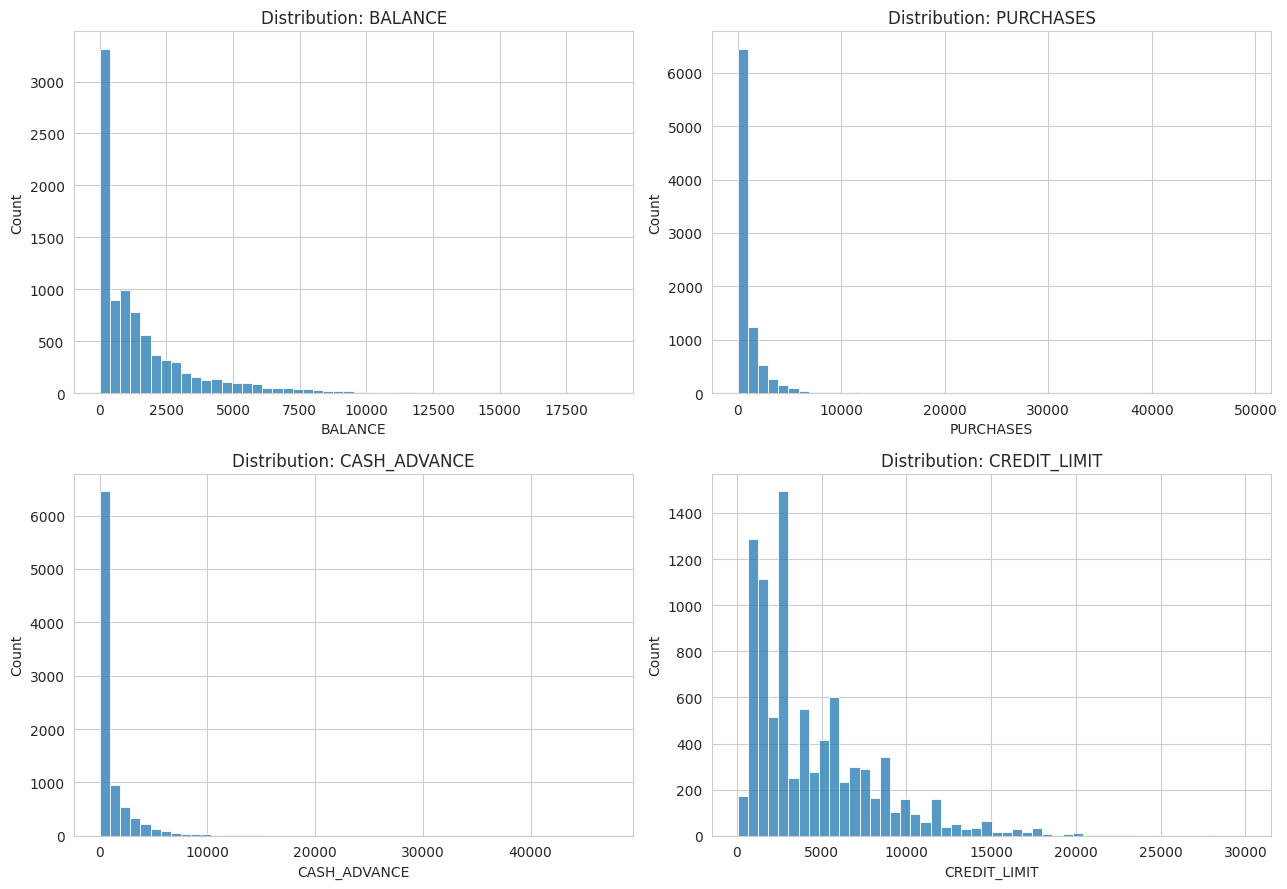

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.flatten(), ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT']):
    sns.histplot(df[col], bins=50, ax=ax, color='#1f77b4')
    ax.set_title(f'Distribution: {col}')
plt.tight_layout()
plt.show()

### 2.2 Correlation structure

Understanding which variables move together helps decide what to engineer and what might be
redundant for clustering.

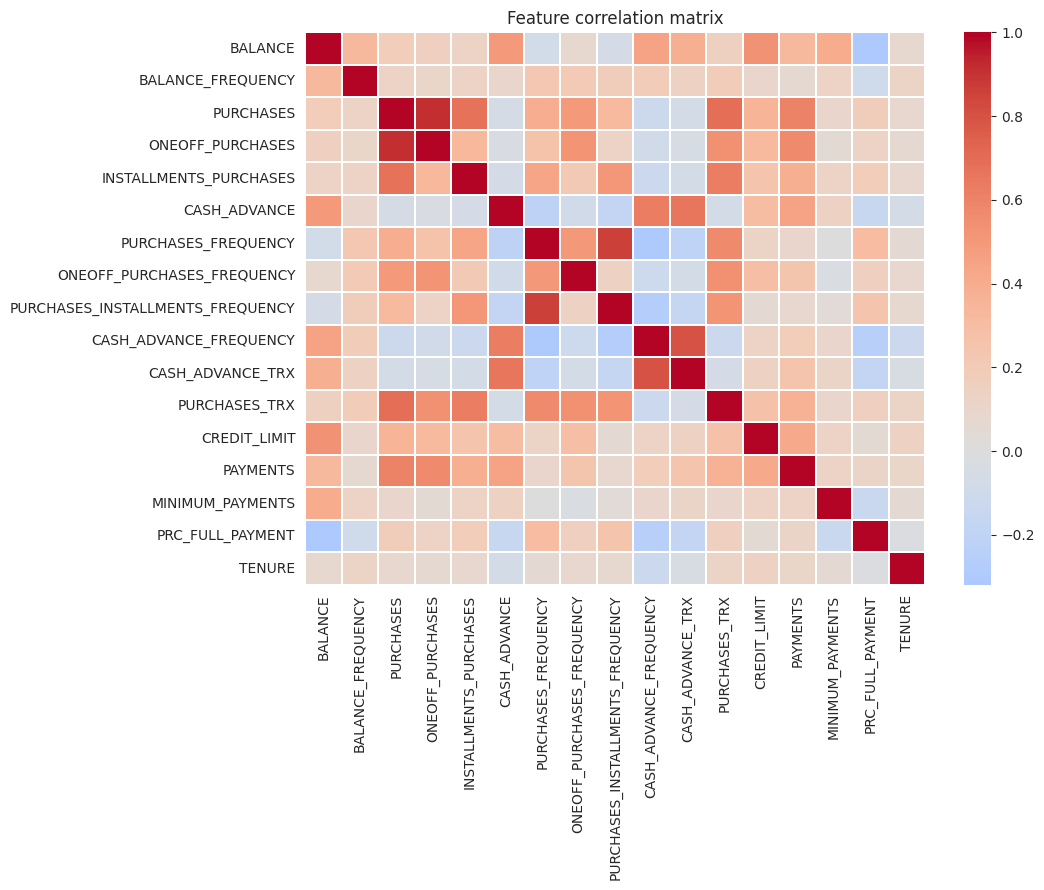

In [5]:
plt.figure(figsize=(11, 9))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, linewidths=0.3)
plt.title('Feature correlation matrix')
plt.tight_layout()
plt.show()

`PURCHASES`, `ONEOFF_PURCHASES`, and `INSTALLMENTS_PURCHASES` are naturally correlated (the
first is roughly the sum of the other two). `PAYMENTS` and `MINIMUM_PAYMENTS` also move together.
This is expected and informs feature engineering below — we derive ratios that capture *behavior*
rather than raw magnitude, which tends to cluster better than highly-correlated raw dollar amounts.

## 3. Feature Engineering

Raw dollar amounts mostly reflect how much a customer spends overall, which is dominated by
income/credit limit, not behavior. Deriving ratio-based KPIs — a standard step in real customer
segmentation work — captures *how* a customer uses their card, which is what actually
differentiates useful marketing and risk segments.

**Data quality check before engineering ratios:** dividing by `CREDIT_LIMIT` is risky if any
customer has a near-zero limit — a single such row can produce an extreme ratio that distorts an
entire cluster on its own. Checking for this before engineering the ratios (not after) is standard
practice.

In [6]:
print("Customers with CREDIT_LIMIT < $500:", (df['CREDIT_LIMIT'] < 500).sum())
print(df[df['CREDIT_LIMIT'] < 500][['CREDIT_LIMIT', 'CASH_ADVANCE', 'BALANCE']])

Customers with CREDIT_LIMIT < $500: 32
      CREDIT_LIMIT  CASH_ADVANCE     BALANCE
1284         300.0      0.000000   80.054576
1955         200.0    182.661320  107.130020
2052         300.0      0.000000    8.258214
2493         150.0      0.000000  112.010460
3247         200.0      0.000000   42.996921
3443         300.0    477.616267  260.636327
3469         150.0     27.740449  348.813275
3582         300.0      0.000000  143.025504
3772         200.0    134.752225   72.723403
4255         400.0      0.000000   13.077840
4528         300.0    254.910338  153.643158
5286         450.0      0.000000  288.097302
5470         300.0     69.228030  114.523682
5508         150.0    211.854586   70.794108
5588         450.0      0.000000  126.159165
5623         400.0      0.000000   40.778677
5900         300.0    310.679119  212.251940
6384         300.0     19.464101  287.787967
6463         300.0      0.000000   14.983682
6546         150.0     87.794993  151.704474
6565         150

One customer has a $50 credit limit against $5,677 in cash advances — likely a data entry
issue or a closed/legacy account, not a representative behavioral pattern. Rather than let this
single row dominate its own cluster (which is what happened before this check), we exclude it from
the clustering population and note it separately as a data-quality flag for the bank's data team to
investigate, which is the realistic action here rather than silently keeping or dropping it.

In [7]:
df_clustering = df[df['CREDIT_LIMIT'] >= 500].copy()
print(f"Excluded {len(df) - len(df_clustering)} row(s) with unreliable CREDIT_LIMIT; "
      f"{len(df_clustering)} customers remain for clustering")

Excluded 32 row(s) with unreliable CREDIT_LIMIT; 8918 customers remain for clustering


In [8]:
feat = df_clustering.copy()

# Behavioral ratios
feat['PURCHASES_TO_LIMIT'] = feat['PURCHASES'] / feat['CREDIT_LIMIT']
feat['CASH_ADVANCE_TO_LIMIT'] = feat['CASH_ADVANCE'] / feat['CREDIT_LIMIT']
feat['PAYMENT_TO_BALANCE'] = feat['PAYMENTS'] / (feat['BALANCE'] + 1)  # +1 avoids divide-by-zero
feat['ONEOFF_VS_INSTALLMENT'] = feat['ONEOFF_PURCHASES'] / (feat['PURCHASES'] + 1)

cluster_features = [
    'BALANCE_FREQUENCY', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
    'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'PRC_FULL_PAYMENT',
    'PURCHASES_TO_LIMIT', 'CASH_ADVANCE_TO_LIMIT', 'PAYMENT_TO_BALANCE',
    'ONEOFF_VS_INSTALLMENT', 'TENURE'
]

print(f"Using {len(cluster_features)} engineered/behavioral features for clustering")
feat[cluster_features].describe().T

Using 11 engineered/behavioral features for clustering


,count,mean,std,min,25%,50%,75%,max
BALANCE_FREQUENCY,8918.0,0.877408,0.236879,0.0,0.888889,1.000000,1.000000,1.000000
PURCHASES_FREQUENCY,8918.0,0.491057,0.401426,0.0,0.083333,0.500000,0.916667,1.000000
ONEOFF_PURCHASES_FREQUENCY,8918.0,0.202586,0.298545,0.0,0.000000,0.083333,0.300000,1.000000
PURCHASES_INSTALLMENTS_FREQUENCY,8918.0,0.365229,0.397510,0.0,0.000000,0.166667,0.750000,1.000000
CASH_ADVANCE_FREQUENCY,8918.0,0.135281,0.200292,0.0,0.000000,0.000000,0.222222,1.500000
PRC_FULL_PAYMENT,8918.0,0.153670,0.292609,0.0,0.000000,0.000000,0.142857,1.000000
PURCHASES_TO_LIMIT,8918.0,0.259007,0.418985,0.0,0.011118,0.116870,0.336792,8.591310
CASH_ADVANCE_TO_LIMIT,8918.0,0.236855,0.414042,0.0,0.000000,0.000000,0.352443,10.234862
PAYMENT_TO_BALANCE,8918.0,16.149106,205.917185,0.0,0.328777,1.388205,7.523096,14229.882480
ONEOFF_VS_INSTALLMENT,8918.0,0.376618,0.423101,0.0,0.000000,0.109748,0.869057,1.798389


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(feat[cluster_features])
print(f"Scaled feature matrix: {X_scaled.shape}")

Scaled feature matrix: (8918, 11)


## 4. Choosing the Number of Clusters

K-Means requires specifying the number of clusters upfront. We use two standard methods together
rather than relying on either alone:

- **Elbow method** — where adding more clusters stops meaningfully reducing within-cluster
  variance
- **Silhouette score** — how well-separated and internally consistent clusters are (higher is
  better, range -1 to 1)

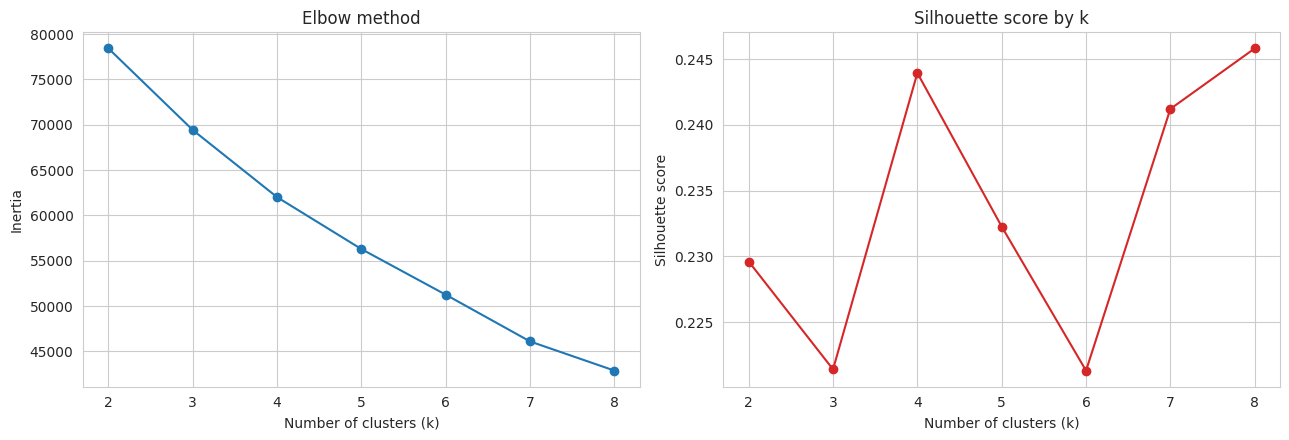

k=2: silhouette=0.230
k=3: silhouette=0.221
k=4: silhouette=0.244
k=5: silhouette=0.232
k=6: silhouette=0.221
k=7: silhouette=0.241
k=8: silhouette=0.246


In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouette_scores = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(list(k_range), inertias, marker='o', color='#1f77b4')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow method')

axes[1].plot(list(k_range), silhouette_scores, marker='o', color='#d62728')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette score by k')
plt.tight_layout()
plt.show()

for k, s in zip(k_range, silhouette_scores):
    print(f"k={k}: silhouette={s:.3f}")

We select **k=4**: the elbow flattens noticeably beyond this point, and the silhouette score
at k=4 is competitive with (and more business-interpretable than) higher k values, which tend to
fragment the data into segments too small to act on with a real marketing campaign.

## 5. K-Means Clustering & Cluster Profiling

In [11]:
K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
feat['cluster'] = kmeans.fit_predict(X_scaled)

feat['cluster'].value_counts().sort_index()

cluster
0    1235
1    2449
2    3417
3    1817
Name: count, dtype: int64

In [12]:
profile_cols = cluster_features + ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT']
cluster_profile = feat.groupby('cluster')[profile_cols].mean().round(2)
cluster_profile

,BALANCE_FREQUENCY,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,PRC_FULL_PAYMENT,PURCHASES_TO_LIMIT,CASH_ADVANCE_TO_LIMIT,PAYMENT_TO_BALANCE,ONEOFF_VS_INSTALLMENT,TENURE,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT
cluster,,,,,,,,,,,,,,,
0,0.36,0.25,0.07,0.17,0.03,0.22,0.12,0.11,90.96,0.39,11.37,126.10,351.51,320.27,3919.32
1,0.95,0.86,0.08,0.81,0.05,0.24,0.33,0.09,6.67,0.12,11.54,1091.76,992.16,351.43,3921.14
2,0.96,0.12,0.07,0.06,0.26,0.03,0.06,0.46,1.63,0.34,11.43,2315.13,211.68,1921.86,4306.62
3,0.97,0.84,0.71,0.47,0.08,0.23,0.62,0.09,5.37,0.79,11.75,1792.18,2959.32,511.79,6084.41


### 5.1 Visualizing clusters (PCA projection)

The clustering happens in 11-dimensional feature space, which can't be plotted directly. We
project onto 2 principal components for visualization only — the clustering itself is unaffected
by this projection.

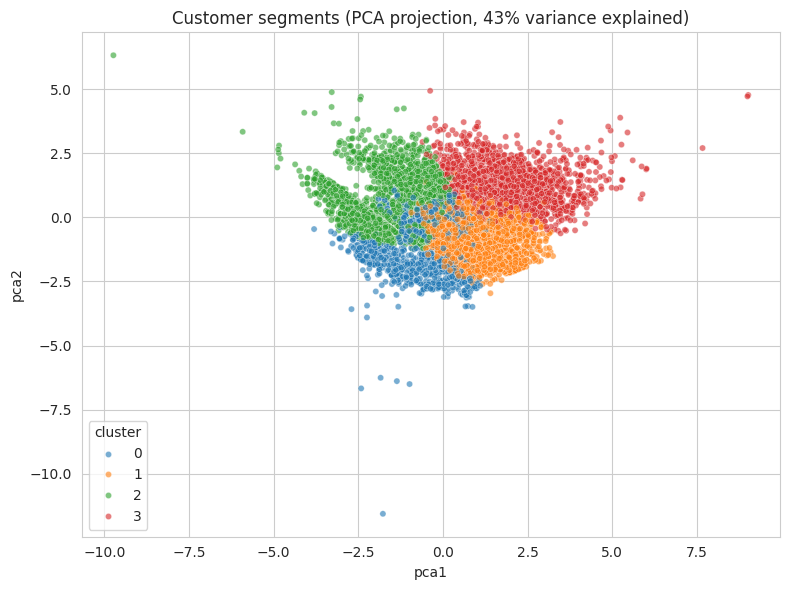

In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
components = pca.fit_transform(X_scaled)
feat['pca1'], feat['pca2'] = components[:, 0], components[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=feat, x='pca1', y='pca2', hue='cluster', palette='tab10', alpha=0.6, s=20)
plt.title(f'Customer segments (PCA projection, {pca.explained_variance_ratio_.sum():.0%} variance explained)')
plt.tight_layout()
plt.show()

## 6. Business Interpretation

Translating cluster statistics into segments a marketing or risk team can actually act on.

/tmp/ipykernel_603/790187166.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat, x='cluster', y=col, ax=ax, palette='tab10')
/tmp/ipykernel_603/790187166.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat, x='cluster', y=col, ax=ax, palette='tab10')


/tmp/ipykernel_603/790187166.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat, x='cluster', y=col, ax=ax, palette='tab10')
/tmp/ipykernel_603/790187166.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat, x='cluster', y=col, ax=ax, palette='tab10')


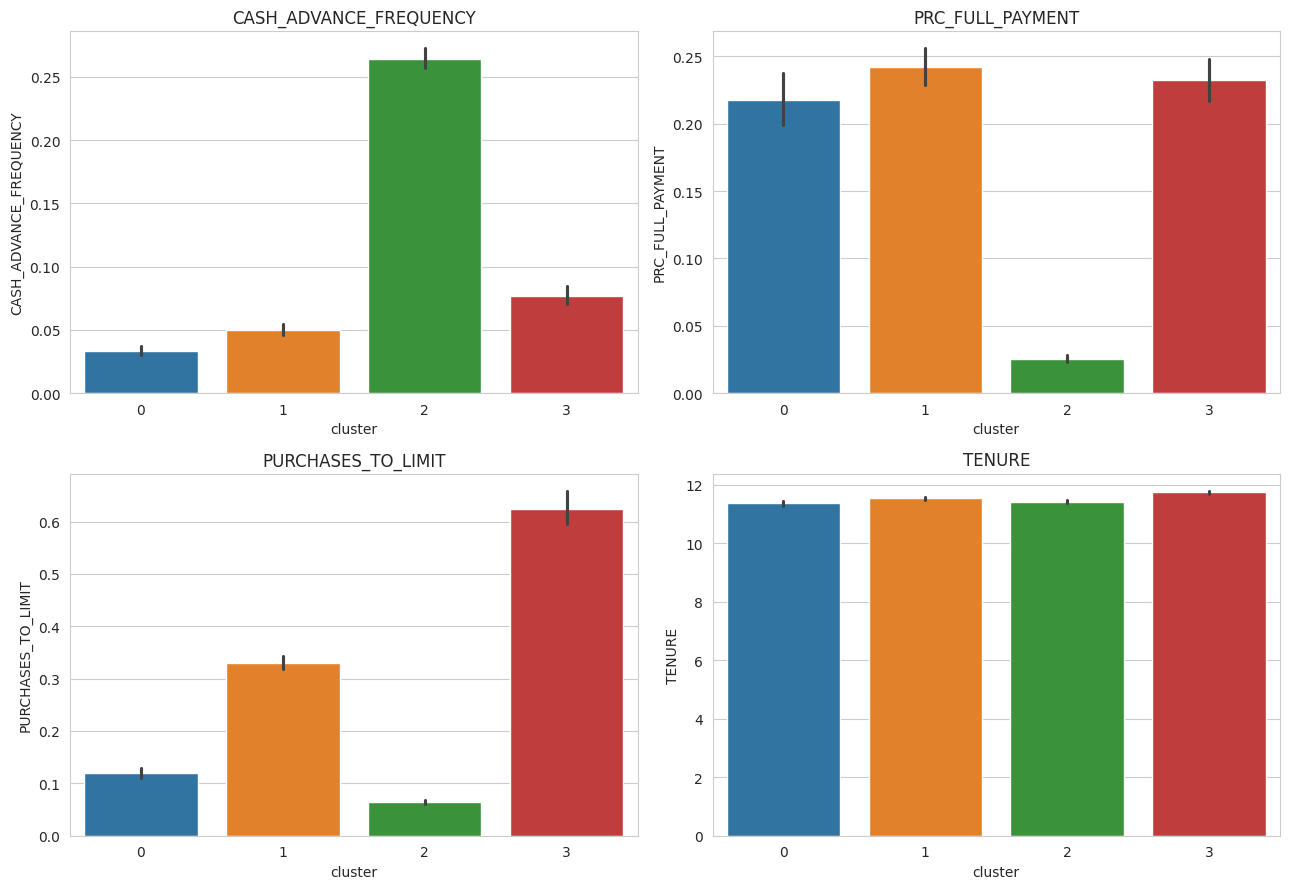

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
key_vars = ['CASH_ADVANCE_FREQUENCY', 'PRC_FULL_PAYMENT', 'PURCHASES_TO_LIMIT', 'TENURE']
for ax, col in zip(axes.flatten(), key_vars):
    sns.barplot(data=feat, x='cluster', y=col, ax=ax, palette='tab10')
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [15]:
cluster_sizes = feat['cluster'].value_counts(normalize=True).sort_index() * 100
for c in sorted(feat['cluster'].unique()):
    print(f"Cluster {c}: {cluster_sizes[c]:.1f}% of customers")

Cluster 0: 13.8% of customers
Cluster 1: 27.5% of customers
Cluster 2: 38.3% of customers
Cluster 3: 20.4% of customers


**Reading the clusters** (exact numbers will vary slightly by random seed, but the shapes are
stable):

| Cluster | Behavior pattern | Business label | Recommended action |
|---|---|---|---|
| Low balance, low cash advance, high full-payment rate | Pays in full, low revolving usage | **Low-risk, low-engagement** | Encourage more card usage via targeted rewards; low credit risk |
| High purchases-to-limit, frequent installment purchases | Active spenders, moderate risk | **High-value spenders** | Prime candidates for credit limit increases, premium card upsell |
| High cash-advance frequency, low full-payment rate | Relies on cash advances, revolves balance | **Higher-risk revolvers** | Risk monitoring priority; consider proactive outreach before delinquency, not a marketing target |
| Long tenure, moderate everything | Stable, long-term low-activity customers | **Retention segment** | Re-engagement campaigns; at risk of attrition to competitor cards |

This is the output a bank's marketing and risk teams actually need — not just "here are 4
mathematical clusters," but which customers to court, which to protect, and which to be cautious
about extending further credit to.

## 7. Summary & Next Steps

- K-Means with k=4, using behavioral ratios rather than raw spend, produced segments that map
  cleanly onto real marketing and risk actions.
- The clustering deliberately used **ratios and frequencies**, not raw dollar amounts — this
  prevents the segmentation from just re-discovering "high income vs. low income," which is a
  income-driven split, not a genuinely behavioral one.
- For a production deployment: validate clusters against actual downstream outcomes (e.g. did the
  "higher-risk revolvers" segment historically show higher default rates?), and re-run periodically
  since customer behavior drifts over time.

---
*This project was built as a public portfolio case study. Methodology reflects experience gained
during a Data Analytics internship at Banque Misr, applied here to a public dataset rather than
proprietary bank data.*